<a href="https://colab.research.google.com/github/aynur214/-heart-disease-analysis/blob/master/Colab'e_ho%C5%9F_geldiniz_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [49]:
import pandas as pd
import numpy as np

Data Collection and Processing

In [50]:
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Exploring the Dataset

In [51]:
# number of rows and columns
df.shape

(303, 14)

In [52]:
# checking for missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [53]:
# statistical summary of the dataset
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [54]:
# checking the distribution of target column
df['target'].value_counts()

,count
target,
1,165
0,138


In [55]:
# age distribution
print(f"Youngest patient: {df['age'].min()}")
print(f"Oldest patient: {df['age'].max()}")
print(f"Average age: {df['age'].mean():.1f}")

Youngest patient: 29
Oldest patient: 77
Average age: 54.4


In [56]:
# gender distribution
print(df['sex'].value_counts())
print("1 = Male, 0 = Female")

sex
1    207
0     96
Name: count, dtype: int64
1 = Male, 0 = Female


In [57]:
# average age by heart disease
print(df.groupby('target')['age'].mean().round(1))
print("0 = No Disease, 1 = Disease")

target
0    56.6
1    52.5
Name: age, dtype: float64
0 = No Disease, 1 = Disease


Data Visualization

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

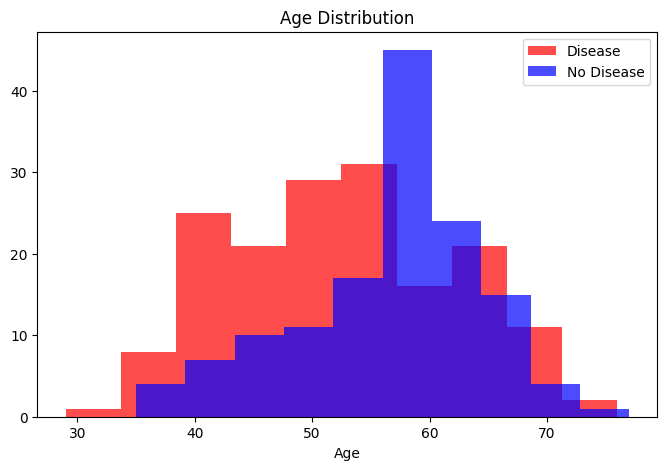

In [59]:
# Age distribution by heart disease
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['target']==1]['age'], alpha=0.7, color='red', label='Disease')
ax.hist(df[df['target']==0]['age'], alpha=0.7, color='blue', label='No Disease')
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.legend()
plt.show()

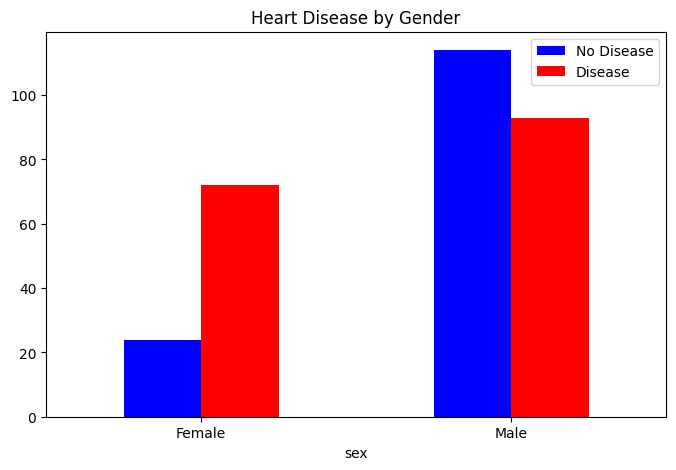

In [60]:
# Heart disease by gender
gender = df.groupby(['sex','target']).size().unstack()
gender.plot(kind='bar', color=['blue','red'], figsize=(8, 5))
plt.title('Heart Disease by Gender')
plt.xticks([0,1], ['Female','Male'], rotation=0)
plt.legend(['No Disease','Disease'])
plt.show()

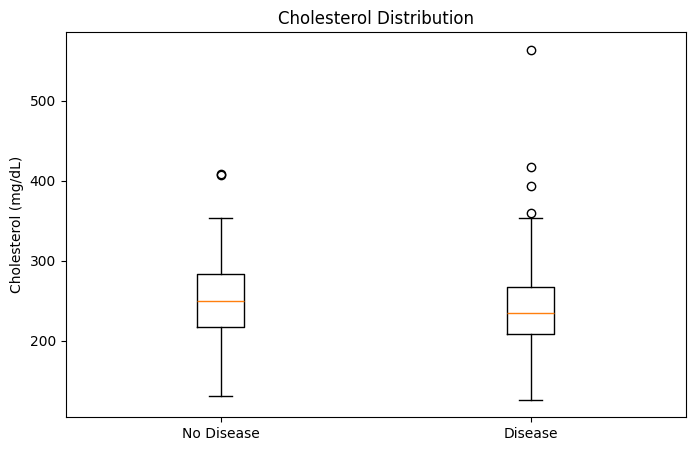

In [61]:
# Cholesterol distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([df[df['target']==0]['chol'], df[df['target']==1]['chol']])
ax.set_title('Cholesterol Distribution')
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_ylabel('Cholesterol (mg/dL)')
plt.show()

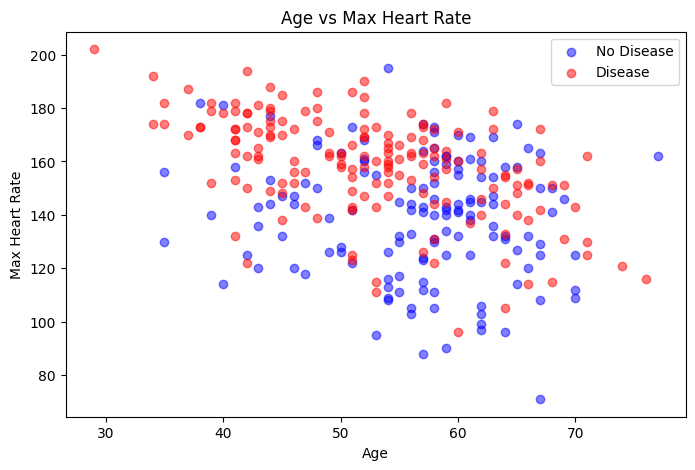

In [62]:
# Age vs Max Heart Rate
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[df['target']==0]['age'], df[df['target']==0]['thalach'],
           alpha=0.5, color='blue', label='No Disease')
ax.scatter(df[df['target']==1]['age'], df[df['target']==1]['thalach'],
           alpha=0.5, color='red', label='Disease')
ax.set_title('Age vs Max Heart Rate')
ax.set_xlabel('Age')
ax.set_ylabel('Max Heart Rate')
ax.legend()
plt.show()

 Correlation Analysis

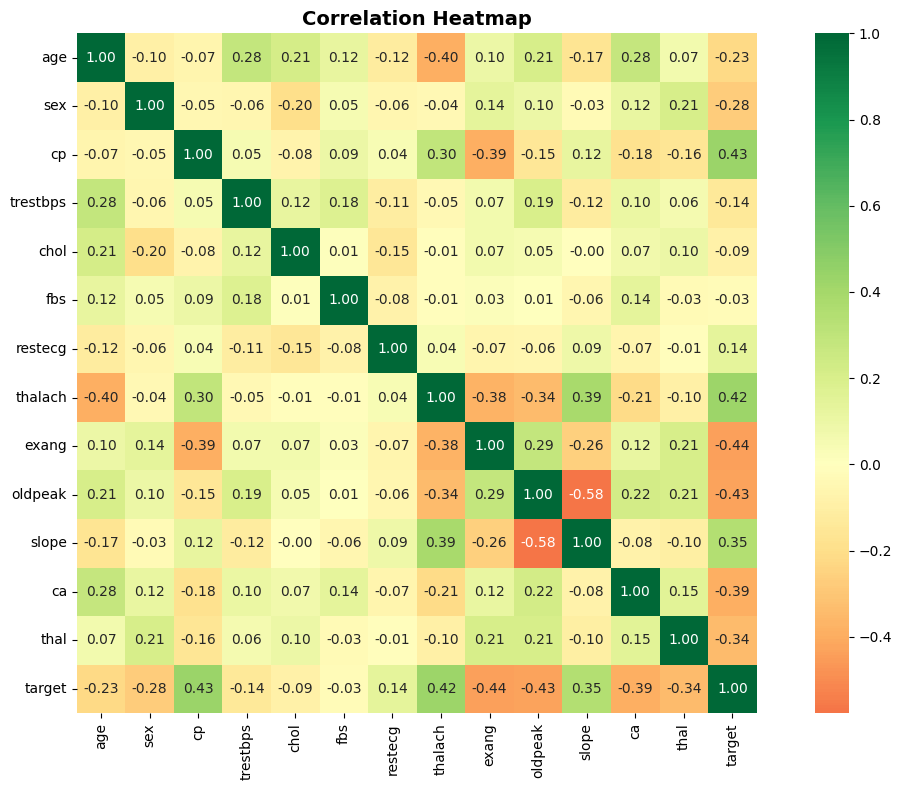

In [63]:
# correlation heatmap
plt.figure(figsize=(12, 8))
correlation = df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
# most correlated features with heart disease
df.corr()['target'].sort_values(ascending=False).round(3)

,target
target,1.000
cp,0.434
thalach,0.422
slope,0.346
restecg,0.137
fbs,-0.028
chol,-0.085
trestbps,-0.145
age,-0.225
sex,-0.281


Key Findings & Conclusion

In [65]:
# dataset summary
total = len(df)
disease = df['target'].sum()
no_disease = total - disease

print(f"Total patients: {total}")
print(f"Heart Disease: {disease} ({disease/total*100:.1f}%)")
print(f"No Heart Disease: {no_disease} ({no_disease/total*100:.1f}%)")

Total patients: 303
Heart Disease: 165 (54.5%)
No Heart Disease: 138 (45.5%)


In [66]:
# gender difference
female_disease = len(df[(df['sex']==0) & (df['target']==1)])
female_total = len(df[df['sex']==0])
male_disease = len(df[(df['sex']==1) & (df['target']==1)])
male_total = len(df[df['sex']==1])

print(f"Female disease rate: {female_disease/female_total*100:.1f}%")
print(f"Male disease rate: {male_disease/male_total*100:.1f}%")

Female disease rate: 75.0%
Male disease rate: 44.9%


In [67]:
# key findings
print("1. Chest pain type is the strongest indicator of heart disease")
print("2. Cholesterol alone is not decisive (correlation: -0.09)")
print(f"3. Patients with heart disease average {df[df['target']==1]['age'].mean():.1f} years old")
print("4. Female disease rate is higher than males")
print("5. Max heart rate is an important risk factor")

1. Chest pain type is the strongest indicator of heart disease
2. Cholesterol alone is not decisive (correlation: -0.09)
3. Patients with heart disease average 52.5 years old
4. Female disease rate is higher than males
5. Max heart rate is an important risk factor


Data Preparation for Power BI

In [68]:
df_powerbi = df.rename(columns={
    'age':      'Age',
    'sex':      'Gender',
    'cp':       'Chest_Pain_Type',
    'trestbps': 'Blood_Pressure',
    'chol':     'Cholesterol',
    'fbs':      'Fasting_Blood_Sugar',
    'thalach':  'Max_Heart_Rate',
    'exang':    'Exercise_Angina',
    'oldpeak':  'Oldpeak',
    'slope':    'Slope',
    'ca':       'Major_Vessels',
    'thal':     'Thal',
    'target':   'Heart_Disease'
})

df_powerbi['Gender'] = df_powerbi['Gender'].map({1: 'Male', 0: 'Female'})
df_powerbi['Heart_Disease'] = df_powerbi['Heart_Disease'].map({1: 'Yes', 0: 'No'})

df_powerbi.to_csv('heart_disease.csv', index=False)
print("✅ Done!")
print(df_powerbi.head(3))

✅ Done!
   Age  Gender  Chest_Pain_Type  Blood_Pressure  Cholesterol  \
0   63    Male                3             145          233   
1   37    Male                2             130          250   
2   41  Female                1             130          204   

   Fasting_Blood_Sugar  restecg  Max_Heart_Rate  Exercise_Angina  Oldpeak  \
0                    1        0             150                0      2.3   
1                    0        1             187                0      3.5   
2                    0        0             172                0      1.4   

   Slope  Major_Vessels  Thal Heart_Disease  
0      0              0     1           Yes  
1      0              0     2           Yes  
2      2              0     2           Yes  


In [69]:
from google.colab import files
files.download('heart_disease.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>